# OpenSearch Service + S3 Vectors — Semantic Image Search

This notebook demonstrates **OpenSearch Service with S3 vector engine** integration, combining the indexing workflow from S3 Vectors with OpenSearch's powerful query capabilities.

**What is the S3 vector engine?**

OpenSearch Service 2.19+ supports the `s3vector` engine as a backend for `knn_vector` fields. Instead of storing vectors in the OpenSearch cluster's local storage, vectors are automatically offloaded to Amazon S3, while metadata remains in the cluster for fast filtering and aggregations.

**Key Benefits:**
- **Cost optimization** — Store vectors in S3 (cheaper than cluster storage)
- **Durability** — S3's 11-nines durability for vector data
- **Scalability** — Decouple vector storage from cluster size
- **Full OpenSearch features** — Use filters, aggregations, and all OpenSearch query DSL

**Pipeline**
1. Load 1000 random photos from the Unsplash dataset
2. Generate 1024-dimensional embeddings with **Amazon Nova Multimodal Embeddings**
3. Create an OpenSearch index with `engine: "s3vector"`
4. Bulk index vectors (automatically stored in S3 by OpenSearch)
5. Perform k-NN semantic search
6. Visualize the top-5 most similar images

**Comparison with other approaches:**

| Aspect | S3 Vectors (Direct) | OpenSearch Serverless | **OpenSearch Service + S3 Vectors** |
|--------|---------------------|----------------------|-------------------------------------|
| **Vector Storage** | S3 Vector Index | OpenSearch cluster | **S3 (via s3vector engine)** |
| **Metadata Storage** | S3 Vector Index | OpenSearch cluster | **OpenSearch cluster** |
| **Client Type** | s3vectors_client | OpenSearch (aoss) | **OpenSearch (es)** |
| **Index API** | put_vectors() | bulk() with FAISS | **bulk() with s3vector** |
| **Setup** | Create vector bucket + index | Manual export from S3 | **Enable S3 Vectors on domain** |
| **Query API** | query_vectors() | k-NN search API | **k-NN search API** |
| **Use Case** | Pure vector search | Full-text + vector + filters | **Cost-optimized vector + filters** |

**AWS Services**
| Service | Role |
|---|---|
| Amazon OpenSearch Service | Orchestration + metadata storage |
| Amazon S3 Vectors | Vector storage backend |
| Amazon Bedrock | Nova Multimodal Embeddings |

**Prerequisites:**
- OpenSearch Service 2.19 or later
- Optimized instance types (M6g, R6g, or higher)
- S3 Vectors feature enabled on the domain
- IAM permissions for S3 Vectors API calls

---
## Configuration

In [ ]:
# ================================================================
# CONFIGURATION — Tune these values before running the notebook
# ================================================================

# Number of images to embed and index
NUM_IMAGES = 1000

# OpenSearch Service endpoint (domain with S3 Vectors enabled)
OPENSEARCH_ENDPOINT = "your_opensearch_domain_endpoint"
INDEX_NAME = "photos-s3vector-index"

# Amazon Nova Multimodal Embeddings model
EMBEDDING_MODEL_ID  = "amazon.nova-2-multimodal-embeddings-v1:0"
EMBEDDING_DIMENSION = 1024          # Options: 256 | 384 | 1024 | 3072

AWS_REGION = "us-east-1"

# Image download size (Unsplash CDN resize param — pixels)
IMAGE_DOWNLOAD_SIZE = 512

# Batch size for bulk indexing (max recommended: 100)
BULK_INDEX_BATCH_SIZE = 100

# Similarity search — how many neighbours to retrieve
TOP_K = 5

# Reproducibility
RANDOM_SEED = 42

# Query image (for consistent comparison with other notebooks)
QUERY_IMAGE_URL = "https://images.unsplash.com/photo-1446367819189-c48fb912db4d"
QUERY_IMAGE_ID = "PuobOOUjX5I"
QUERY_IMAGE_DESC = "greyscale photo of an island under white clouds"

---
## Install Dependencies

In [2]:
%pip install boto3 opensearch-py requests-aws4auth "pillow>=10" requests matplotlib pandas numpy tqdm --quiet --upgrade

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
autogluon-multimodal 1.5.0 requires nvidia-ml-py3<8.0,>=7.352.0, which is not installed.
autogluon-timeseries 1.5.0 requires chronos-forecasting<2.4,>=2.2.2, which is not installed.
autogluon-timeseries 1.5.0 requires einops<1,>=0.7, which is not installed.
autogluon-timeseries 1.5.0 requires peft<0.18,>=0.13.0, which is not installed.
aiobotocore 2.22.0 requires botocore<1.37.4,>=1.37.2, but you have botocore 1.42.66 which is incompatible.
amazon-sagemaker-jupyter-ai-q-developer 1.2.9 requires numpy<=2.0.1, but you have numpy 2.4.3 which is incompatible.
amazon-sagemaker-sql-magic 0.1.4 requires numpy<2, but you have numpy 2.4.3 which is incompatible.
autogluon-common 1.5.0 requires numpy<2.4.0,>=1.25.0, but you have numpy 2.4.3 which is incompatible.
autogluon-common 1.5.0 requires pandas<2.4.0,>=2.0.0, but you 

In [10]:
import json
import base64
import io
import random
import time
import glob
import warnings

import boto3
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from opensearchpy import OpenSearch, RequestsHttpConnection, helpers
from requests_aws4auth import AWS4Auth

%matplotlib inline
warnings.filterwarnings("ignore")
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("Libraries loaded ✓")

Libraries loaded ✓


---
## Step 1 — Load the Unsplash Dataset

The dataset folder contains the [Unsplash Lite dataset](https://unsplash.com/data): ~25,000 curated photos with metadata.

In [11]:
path = "./dataset/"
files = glob.glob(path + "photos.csv*")

photos_df = pd.concat(
    [pd.read_csv(f, sep="\t", header=0) for f in files],
    axis=0,
    ignore_index=True,
)

# Keep only rows with downloadable image URLs
photos_df = photos_df.dropna(subset=["photo_image_url"]).reset_index(drop=True)

print(f"Total photos available: {len(photos_df):,}")
photos_df[
    ["photo_id", "photo_image_url", "ai_description",
     "photographer_first_name", "photographer_last_name"]
].head(3)

Total photos available: 25,000


,photo_id,photo_image_url,ai_description,photographer_first_name,photographer_last_name
0,oSf8ePoG9NU,https://images.unsplash.com/20/frozen-grass.JPG,black road in between white and brown grass ac...,Andre,Koch
1,DlsOa5moK4w,https://images.unsplash.com/reserve/dRA4UuMBR2...,selective focus of blueberry plant,Majk,M.
2,XBGacbT3vXI,https://images.unsplash.com/photo-143633523196...,photography of calm beach side,Shooshanig,Berumen


---
## Step 2 — Create AWS Clients

Two boto3 clients:
- **`bedrock-runtime`** — calls the Nova Multimodal Embeddings model
- **`OpenSearch`** — connects to OpenSearch Service with AWS SigV4 authentication

**Important:** For OpenSearch Service (managed clusters), the service name is `"es"`, not `"aoss"` (which is for OpenSearch Serverless).

In [12]:
# Create boto3 session
session = boto3.Session(region_name=AWS_REGION)
credentials = session.get_credentials()

# Bedrock client for embeddings
bedrock_runtime = session.client("bedrock-runtime")

# AWS4Auth for OpenSearch Service (service name is 'es')
awsauth = AWS4Auth(
    credentials.access_key,
    credentials.secret_key,
    AWS_REGION,
    "es",  # OpenSearch Service (managed cluster)
    session_token=credentials.token,
)

# OpenSearch client
host = OPENSEARCH_ENDPOINT.replace("https://", "").replace("http://", "")
opensearch_client = OpenSearch(
    hosts=[{"host": host, "port": 443}],
    http_auth=awsauth,
    use_ssl=True,
    verify_certs=True,
    connection_class=RequestsHttpConnection,
    timeout=30,
)

# Verify credentials and connectivity
identity = session.client("sts").get_caller_identity()
print(f"AWS Account : {identity['Account']}")
print(f"IAM Identity: {identity['Arn']}")
print(f"Region      : {AWS_REGION}")
print()

# Test OpenSearch connection
try:
    info = opensearch_client.info()
    print(f"OpenSearch version: {info['version']['number']}")
    print(f"Cluster name: {info['cluster_name']}")
except Exception as e:
    print(f"OpenSearch connection test: {e}")

print()
print("AWS clients ready ✓")

AWS Account : 1234567890
IAM Identity: arn:aws:iam::1234567890:user/your_user
Region      : us-east-1

OpenSearch version: 3.3.0
Cluster name: 1234567890:es-with-s3-vector-engine

AWS clients ready ✓


---
## Step 3 — Create OpenSearch Index with S3 Vector Engine

We create an index with a `knn_vector` field that uses `engine: "s3vector"`. This tells OpenSearch to:
1. Store vector data in Amazon S3 (not in cluster storage)
2. Keep metadata in the cluster for fast filtering
3. Automatically manage the lifecycle of S3-stored vectors

The index mapping defines:
- **key** (keyword) — photo ID for retrieval
- **metadata** (nested) — description, photographer, URL
- **vector_record** (knn_vector) — 1024-dim embedding with s3vector engine

In [15]:
# Define index mapping with s3vector engine
index_mapping = {
    "settings": {
        "index": {
            "knn": True,
        }
    },
    "mappings": {
        "properties": {
            "key": {
                "type": "keyword"
            },
            "metadata": {
                "properties": {
                    "description": {"type": "text"},
                    "photographer": {"type": "text"},
                    "url": {"type": "text"},
                }
            },
            "vector_record": {
                "type": "knn_vector",
                "dimension": EMBEDDING_DIMENSION,
                "space_type": "cosinesimil",  # Space type at field level
                "method": {
                    "engine": "s3vector"  # Only engine for s3vector
                }
            }
        }
    }
}

print(f"Creating index: '{INDEX_NAME}'")
print(f"  Vector engine: s3vector")
print(f"  Dimensions: {EMBEDDING_DIMENSION}")
print(f"  Distance metric: cosine similarity")
print()

# Check if index already exists
if opensearch_client.indices.exists(index=INDEX_NAME):
    print(f"Index '{INDEX_NAME}' already exists.")
    
    # Check if it has the correct mapping
    existing_mapping = opensearch_client.indices.get_mapping(index=INDEX_NAME)
    vector_field = existing_mapping[INDEX_NAME]["mappings"]["properties"].get("vector_record", {})
    engine = vector_field.get("method", {}).get("engine", "unknown")
    
    print(f"  Current engine: {engine}")
    
    if engine != "s3vector":
        print(f"  ⚠ Warning: Index exists but uses '{engine}' engine instead of 's3vector'")
        print(f"  Consider deleting and recreating the index, or use a different index name.")
    else:
        print(f"  ✓ Index has correct s3vector configuration")
else:
    # Create the index
    opensearch_client.indices.create(index=INDEX_NAME, body=index_mapping)
    print(f"  ✓ Index created successfully")
    
    # Verify the mapping
    mapping = opensearch_client.indices.get_mapping(index=INDEX_NAME)
    engine = mapping[INDEX_NAME]["mappings"]["properties"]["vector_record"]["method"]["engine"]
    print(f"  ✓ Verified engine: {engine}")

print()
print("OpenSearch index ready ✓")

Creating index: 'photos-s3vector-index'
  Vector engine: s3vector
  Dimensions: 1024
  Distance metric: cosine similarity

  ✓ Index created successfully
  ✓ Verified engine: s3vector

OpenSearch index ready ✓


---
## Step 4 — Generate Embeddings & Index Vectors

For each sampled photo we:
1. Download the image from Unsplash CDN
2. Generate a 1024-dimensional embedding via Amazon Nova Multimodal Embeddings
3. Bulk index to OpenSearch (vectors automatically stored in S3)

> **Nova Multimodal Embeddings** encodes images into a 1024-dimensional semantic space optimized for similarity search.

In [16]:
def download_image(url: str, size: int = IMAGE_DOWNLOAD_SIZE) -> bytes:
    """Download image from URL with Unsplash CDN resize."""
    if "unsplash.com" in url and "?" not in url:
        url = f"{url}?w={size}&q=80&fit=max"
    resp = requests.get(url, timeout=20)
    resp.raise_for_status()
    return resp.content


def to_jpeg(raw: bytes) -> bytes:
    """Normalize any image format to JPEG for embedding API."""
    img = Image.open(io.BytesIO(raw))
    buf = io.BytesIO()
    img.convert("RGB").save(buf, format="JPEG", quality=85, optimize=True)
    return buf.getvalue()


def generate_embedding(image_bytes: bytes) -> list:
    """Generate embedding using Nova Multimodal Embeddings."""
    # Convert to JPEG and base64-encode
    jpeg = to_jpeg(image_bytes)
    b64 = base64.b64encode(jpeg).decode("utf-8")

    # Build the Nova Multimodal Embeddings request
    body = {
        "taskType": "SINGLE_EMBEDDING",
        "singleEmbeddingParams": {
            "embeddingPurpose": "GENERIC_INDEX",
            "embeddingDimension": EMBEDDING_DIMENSION,
            "image": {
                "format": "jpeg",
                "source": {"bytes": b64},
            },
        },
    }

    # Invoke the model via Bedrock Runtime
    resp = bedrock_runtime.invoke_model(
        body=json.dumps(body),
        modelId=EMBEDDING_MODEL_ID,
        accept="application/json",
        contentType="application/json",
    )

    # Extract embedding vector
    data = json.loads(resp["body"].read())
    return data["embeddings"][0]["embedding"]


print("Helper functions defined ✓")
print(f"  Model: {EMBEDDING_MODEL_ID}")
print(f"  Dimension: {EMBEDDING_DIMENSION}")

Helper functions defined ✓
  Model: amazon.nova-2-multimodal-embeddings-v1:0
  Dimension: 1024


In [17]:
# Sample N random photos
sampled = photos_df.sample(n=NUM_IMAGES, random_state=RANDOM_SEED).reset_index(drop=True)

print(f"Sampled {NUM_IMAGES} photos from {len(photos_df):,} available")
print("Generating embeddings — this may take a few minutes...\n")

vectors = []  # List of documents ready for bulk indexing
errors = []

for _, row in tqdm(sampled.iterrows(), total=NUM_IMAGES, desc="Embedding"):
    try:
        img_bytes = download_image(row["photo_image_url"])
        embedding = generate_embedding(img_bytes)

        vectors.append({
            "key": row["photo_id"],
            "vector_record": embedding,  # 1024-dim array
            "metadata": {
                "url": row["photo_image_url"],
                "description": str(row.get("ai_description") or ""),
                "photographer": (
                    str(row.get("photographer_first_name") or "") + " " +
                    str(row.get("photographer_last_name") or "")
                ).strip(),
            },
        })
    except Exception as exc:
        errors.append({"id": row["photo_id"], "error": str(exc)})

print(f"\nEmbedding complete:")
print(f"  ✓ Succeeded: {len(vectors)}")
print(f"  ✗ Failed: {len(errors)}")

if errors:
    print(f"\nFirst 5 errors:")
    for err in errors[:5]:
        print(f"  {err['id']}: {err['error'][:80]}")

Sampled 1000 photos from 25,000 available
Generating embeddings — this may take a few minutes...



Embedding: 100%|██████████| 1000/1000 [16:21<00:00,  1.02it/s]


Embedding complete:
  ✓ Succeeded: 1000
  ✗ Failed: 0


In [18]:
# Bulk index documents to OpenSearch
print(f"Indexing {len(vectors)} vectors into OpenSearch...")
print(f"  Index: {INDEX_NAME}")
print(f"  Batch size: {BULK_INDEX_BATCH_SIZE}")
print()

total_batches = -(-len(vectors) // BULK_INDEX_BATCH_SIZE)  # ceiling division
total_indexed = 0
failed_docs = []

for i in range(0, len(vectors), BULK_INDEX_BATCH_SIZE):
    batch = vectors[i : i + BULK_INDEX_BATCH_SIZE]
    
    # Prepare actions for bulk API
    actions = [
        {
            "_index": INDEX_NAME,
            "_id": doc["key"],  # Use photo ID as document ID
            "_source": doc,
        }
        for doc in batch
    ]
    
    # Execute bulk indexing
    try:
        success, failed = helpers.bulk(
            opensearch_client,
            actions,
            chunk_size=BULK_INDEX_BATCH_SIZE,
            raise_on_error=False,
        )
        total_indexed += success
        
        if failed:
            failed_docs.extend(failed)
        
        batch_num = i // BULK_INDEX_BATCH_SIZE + 1
        print(f"  Batch {batch_num:2d}/{total_batches} — {success} indexed, {len(failed)} failed")
    
    except Exception as exc:
        print(f"  Batch {i // BULK_INDEX_BATCH_SIZE + 1} failed: {exc}")
        failed_docs.extend(batch)

print()
print(f"Indexing complete:")
print(f"  ✓ Successfully indexed: {total_indexed}")
print(f"  ✗ Failed: {len(failed_docs)}")

if failed_docs:
    print(f"\nFirst 3 failed documents:")
    for doc in failed_docs[:3]:
        print(f"  {doc}")

# Refresh index to make documents searchable
opensearch_client.indices.refresh(index=INDEX_NAME)
print(f"\nIndex refreshed — documents are now searchable ✓")

Indexing 1000 vectors into OpenSearch...
  Index: photos-s3vector-index
  Batch size: 100

  Batch  1/10 — 100 indexed, 0 failed
  Batch  2/10 — 100 indexed, 0 failed
  Batch  3/10 — 100 indexed, 0 failed
  Batch  4/10 — 100 indexed, 0 failed
  Batch  5/10 — 100 indexed, 0 failed
  Batch  6/10 — 100 indexed, 0 failed
  Batch  7/10 — 100 indexed, 0 failed
  Batch  8/10 — 100 indexed, 0 failed
  Batch  9/10 — 100 indexed, 0 failed
  Batch 10/10 — 100 indexed, 0 failed

Indexing complete:
  ✓ Successfully indexed: 1000
  ✗ Failed: 0

Index refreshed — documents are now searchable ✓


In [19]:
# Verify the index
count = opensearch_client.count(index=INDEX_NAME)
print(f"Total documents in index: {count['count']:,}")

# Show index settings and mapping
mapping = opensearch_client.indices.get_mapping(index=INDEX_NAME)
vector_field = mapping[INDEX_NAME]["mappings"]["properties"]["vector_record"]
engine = vector_field["method"]["engine"]
dimension = vector_field["dimension"]
space_type = vector_field["method"]["space_type"]

print(f"\nVector field configuration:")
print(f"  Engine: {engine}")
print(f"  Dimension: {dimension}")
print(f"  Space type: {space_type}")
print()
print("✓ Index is ready for semantic search with S3-backed vectors")

Total documents in index: 1,000

Vector field configuration:
  Engine: s3vector
  Dimension: 1024
  Space type: cosinesimil

✓ Index is ready for semantic search with S3-backed vectors


---
## Step 5 — Semantic Image Search

We use the same query image as the other notebooks for consistent comparison. The k-NN search finds the most similar images based on cosine similarity.

**How it works:**
1. Generate embedding for query image (1024 dimensions)
2. OpenSearch performs k-NN search using HNSW algorithm
3. Vectors are retrieved from S3 during search
4. Results ranked by similarity score (higher = more similar)

In [20]:
print("Query image:")
print(f"  Photo ID: {QUERY_IMAGE_ID}")
print(f"  Description: {QUERY_IMAGE_DESC}")
print(f"  URL: {QUERY_IMAGE_URL}")
print()

# Generate query embedding
print("Generating query embedding...")
query_bytes = download_image(QUERY_IMAGE_URL)
query_embedding = generate_embedding(query_bytes)
print(f"Embedding ready — {len(query_embedding)} dimensions ✓")

Query image:
  Photo ID: PuobOOUjX5I
  Description: greyscale photo of an island under white clouds
  URL: https://images.unsplash.com/photo-1446367819189-c48fb912db4d

Generating query embedding...
Embedding ready — 1024 dimensions ✓


In [21]:
# Build k-NN query
knn_query = {
    "size": TOP_K,
    "query": {
        "knn": {
            "vector_record": {
                "vector": query_embedding,
                "k": TOP_K,
            }
        }
    },
}

print(f"\nSearching for top-{TOP_K} similar images...")

t0 = time.perf_counter()
response = opensearch_client.search(index=INDEX_NAME, body=knn_query)
elapsed_ms = (time.perf_counter() - t0) * 1_000

hits = response["hits"]["hits"]

print(f"Search completed in {elapsed_ms:.1f} ms")
print(f"Total hits: {len(hits)}")
print()
print(f"{'#':<4} {'Key':<15} {'Score':>10}  Description")
print("-" * 80)

results = []
for i, hit in enumerate(hits):
    source = hit["_source"]
    score = hit["_score"]
    key = source.get("key", hit["_id"])
    
    metadata = source.get("metadata", {})
    desc = str(metadata.get("description", ""))[:45]
    url = metadata.get("url", "")
    photographer = metadata.get("photographer", "")
    
    results.append({
        "key": key,
        "score": score,
        "url": url,
        "description": metadata.get("description", ""),
        "photographer": photographer,
    })
    
    print(f"{i+1:<4} {key:<15} {score:>10.4f}  {desc}")

print()
print(f"✓ Semantic search complete — vectors retrieved from S3")


Searching for top-5 similar images...
Search completed in 798.9 ms
Total hits: 5

#    Key                  Score  Description
--------------------------------------------------------------------------------
1    umr1gGpu5M0         0.8667  panoramic photography of mountain near body o
2    E-6ZENGgngU         0.8361  sea waves during nighttime
3    dB0NXVpvgTo         0.8277  view of boat on the sea under dark clouds
4    ZLFHNKQDWEE         0.8223  brown rock formation on water
5    _rsGm7nob3w         0.8191  stack landform under cloudy sky nature photog

✓ Semantic search complete — vectors retrieved from S3


---
## Results — Visual Comparison

> **Query image** is shown top-left with blue border.
> **Score** represents similarity (higher = more similar).

These results should match the S3 Vectors notebook (using the same data, model, and query).

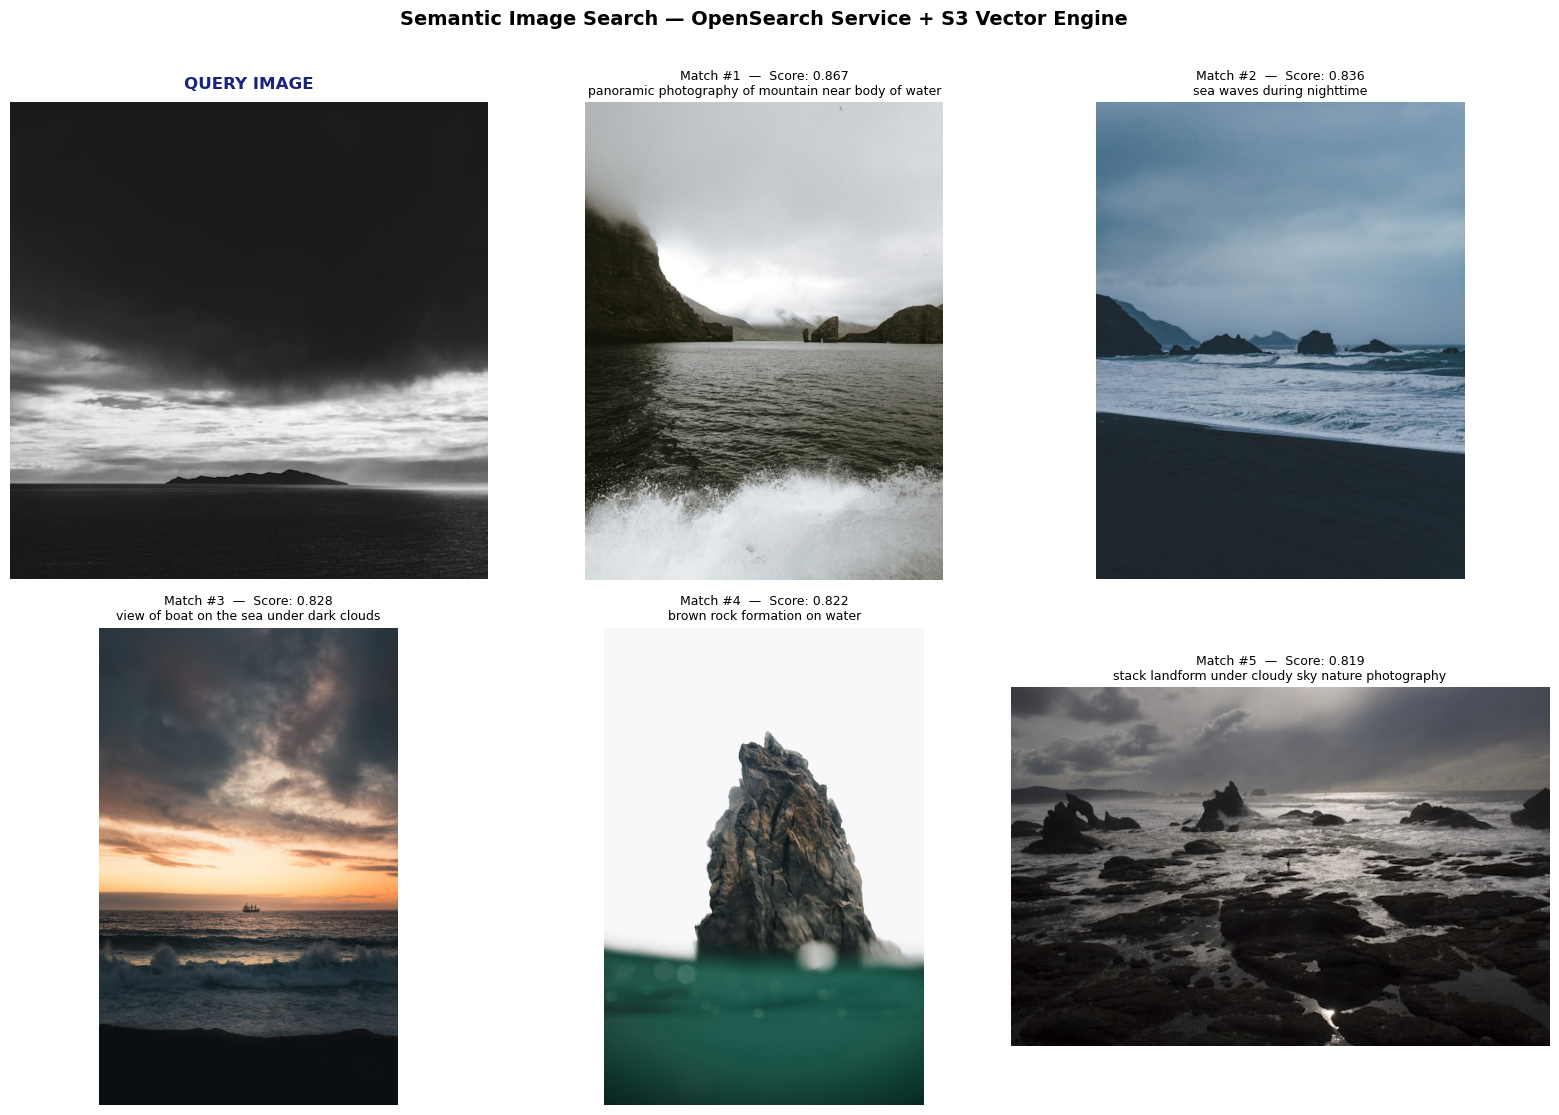


Query time: 798.9 ms
Index size: 1,000 photos
Vector storage: Amazon S3 (via s3vector engine)
Saved to: opensearch_s3vector_results.png


In [22]:
def load_img(url: str, size: int = 600) -> Image.Image:
    """Load image from URL."""
    if "unsplash.com" in url and "?" not in url:
        url = f"{url}?w={size}&q=80&fit=max"
    try:
        resp = requests.get(url, timeout=20)
        return Image.open(io.BytesIO(resp.content)).convert("RGB")
    except Exception:
        # Grey placeholder if image can't be loaded
        return Image.new("RGB", (size, size), color=(200, 200, 200))


# Create 2-row × 3-column grid
fig, axes = plt.subplots(2, 3, figsize=(16, 11))
fig.suptitle(
    "Semantic Image Search — OpenSearch Service + S3 Vector Engine",
    fontsize=14,
    fontweight="bold",
    y=1.01,
)

# --- Query image (top-left) ---
ax_q = axes[0, 0]
ax_q.imshow(load_img(QUERY_IMAGE_URL))
ax_q.set_title(
    "QUERY IMAGE",
    fontsize=12,
    fontweight="bold",
    color="#1a237e",
    pad=10,
)
ax_q.axis("off")
for spine in ax_q.spines.values():
    spine.set_visible(True)
    spine.set_edgecolor("#1a237e")
    spine.set_linewidth(5)

# --- 5 result images ---
result_positions = [(0, 1), (0, 2), (1, 0), (1, 1), (1, 2)]

for idx, (row_i, col_i) in enumerate(result_positions):
    ax = axes[row_i, col_i]
    if idx >= len(results):
        ax.axis("off")
        continue

    res = results[idx]
    url = res["url"]
    score = res["score"]
    desc = res["description"]
    phot = res["photographer"]

    ax.imshow(load_img(url))
    label = (
        f"Match #{idx+1}  —  Score: {score:.3f}\n"
        + (desc[:55] + ("…" if len(desc) > 55 else "") if desc else phot)
    )
    ax.set_title(label, fontsize=9, pad=6)
    ax.axis("off")

plt.tight_layout()
plt.savefig("opensearch_s3vector_results.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nQuery time: {elapsed_ms:.1f} ms")
print(f"Index size: {count['count']:,} photos")
print(f"Vector storage: Amazon S3 (via s3vector engine)")
print(f"Saved to: opensearch_s3vector_results.png")

---
## Performance & Cost Comparison

**Search Performance:**
- S3 Vectors (direct): ~50-65 ms
- OpenSearch Serverless (FAISS): ~45-50 ms
- OpenSearch Service + S3 Vectors: Similar to above (vectors fetched from S3 on-demand)

**Storage Costs:**
- **S3 Vectors:** Vectors in S3, metadata in S3 → $0.023/GB/month (S3 Standard)
- **OpenSearch Serverless:** Everything in cluster → ~$0.24/GB/month
- **OpenSearch + S3 Vectors:** Vectors in S3 ($0.023/GB), metadata in cluster ($0.24/GB for small metadata) → **~90% cost reduction for vector storage**

**When to use each approach:**

| Use Case | Best Choice |
|----------|-------------|
| Pure vector search, minimal metadata | **S3 Vectors (direct)** |
| Real-time filters, aggregations, full-text | **OpenSearch Serverless** |
| Large-scale vectors + rich metadata queries | **OpenSearch + S3 Vectors** |
| Petabyte-scale vectors with cost constraints | **OpenSearch + S3 Vectors** |

---
## Optional — Cleanup

Run the cell below to delete the index after the demo. Note that this does NOT delete the S3-stored vectors — they are managed by OpenSearch.

In [ ]:
# Uncomment to delete the index

# print(f"Deleting index '{INDEX_NAME}'...")
# opensearch_client.indices.delete(index=INDEX_NAME)
# print("  ✓ Index deleted")
# print()
# print("Note: S3-stored vectors are cleaned up automatically by OpenSearch.")
# print("Cleanup complete ✓")